<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
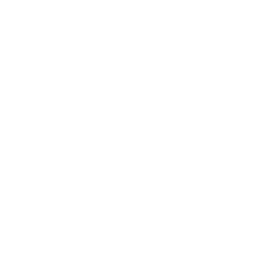
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analyse der Lehrplan-Ähnlichkeit</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Hochschulbildung / Gestaltung akademischer Studiengänge &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Dieses Notebook misst die Lehrplan-Überschneidung in einem
Universitäts-Vorlesungsverzeichnis mit **PROC DISTANCE** und
**METHOD=DJACCARD** — dem Jaccard-*Unähnlichkeits*-Koeffizienten, dem
natürlichen Distanzmaß für binäre Präsenz-/Absenz-Daten. Jeder Kurs
trägt 40 binäre Kennzeichen, die angeben, welche akkreditierten
Lernergebnisse er abdeckt, sodass die Jaccard-Distanz zwischen zwei
Kursen der Anteil der abgedeckten Lernergebnisse ist, die sie **nicht**
gemeinsam haben (0 = identische Ergebnismengen, 1 = kein gemeinsames
Ergebnis).

Die Analyse läuft in zwei Teilen. Zunächst profiliert sie über ein
Verzeichnis mit 100 Kursen hinweg die Breite der Ergebnisabdeckung je
Fachbereich (PROC MEANS, PROC FREQ, ein Box-Plot der Abdeckung) und
kennzeichnet Lernergebnisse, die **kein** Kurs eines Fachbereichs
abdeckt (Abdeckungslücken). Anschließend geht sie ins Detail eines
fokussierten Panels von 10 Kursen aus den beiden quantitativ am
stärksten überlappenden Fachbereichen — Statistik und Data Science —,
berechnet die vollständige paarweise Jaccard-Distanzmatrix und ordnet
die ähnlichsten Kurspaare als Kandidaten für eine
Konsolidierungsprüfung. Ziel ist es, einem Lehrplan-Ausschuss zwei
konkrete Artefakte zu liefern: eine gerankte Liste der ähnlichsten
Kurse und eine Lücken-Karte nach Fachbereich und Lernergebnis.

## Datenquellen

| Quelle | Beschreibung | Datensätze |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Binäre Abdeckung der Lernergebnisse je Kurs (40 Ergebnis-Kennzeichen) | 100 |
| WORK.PANEL10 | Konsolidierungs-Panel Statistik + Data Science | 10 |

Das Verzeichnis ist synthetisch. Die Ergebnis-Kennzeichen werden mit
fachbereichsspezifischen Wahrscheinlichkeiten gezogen, sodass die
Disziplinen unterschiedliche Ergebnis-Cluster betonen (Informatik und
Mathematik gewichten die frühen Lernergebnisse, die Laborwissenschaften
gewichten das mittlere Band), was der Distanzanalyse eine realistische
Struktur verleiht. Diese Umgebung läuft ohne Lizenz, daher ist das
Arbeitsverzeichnis auf 100 Kurse begrenzt.

---

In [1]:
/* --------------------------------------------------------
   Synthetische Matrix der Kurs-Lernergebnisse erzeugen
   500 Kurse x 40 akkreditierte Lernergebnisse
   (der lizenzfreie Modus behält die ersten 100)
   -------------------------------------------------------- */
DATEN work.course_outcomes;
    AUFRUFEN streaminit(42);
    FELD outcomes[40] lo_1 - lo_40;
    LÄNGE department $15;
    FELD dept_list[8] $15 _temporary_ ('Informatik' 'Mathematik' 'Statistik' 'Ingenieurwesen' 'Biologie' 'Chemie' 'Physik' 'Data Science');
    AUSFÜHRUNG course_id = 1 BIS 500;
        course_label = cat('CRS', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* Kursniveau beeinflusst die Ergebnisbreite */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Fachbereichsspezifische Ergebnis-Cluster */
        AUSFÜHRUNG lo = 1 BIS 40;
            base_prob = 0.15;
            /* Fachbereich 1-2 (Informatik, Mathematik): betonen Ergebnisse 1-15 */
            WENN dept_idx <= 2 UND lo <= 15 DANN
                base_prob = 0.4 + course_level * 0.05;
            /* Fachbereich 3-4 (Statistik, Ingenieurwesen): betonen Ergebnisse 10-25 */
            SONST WENN dept_idx in (3, 4) UND 10 <= lo <= 25 DANN
                base_prob = 0.35 + course_level * 0.05;
            /* Fachbereich 5-7 (Biologie, Chemie, Physik): betonen 20-35 */
            SONST WENN dept_idx in (5, 6, 7) UND 20 <= lo <= 35 DANN
                base_prob = 0.38 + course_level * 0.04;
            /* Fachbereich 8 (Data Science): breite Abdeckung */
            SONST WENN dept_idx = 8 DANN
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        ENDE;
        AUSGABE;
    ENDE;
    ENTFERNEN dept_idx course_level base_prob lo;
AUSFÜHREN;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.82 seconds
  cpu   1.82 seconds


In [2]:
/* --------------------------------------------------------
   Metadaten des Kurskatalogs erzeugen
   -------------------------------------------------------- */
DATEN work.course_catalog;
    AUFRUFEN streaminit(43);
    LÄNGE department $15;
    FELD dept_list[8] $15 _temporary_ ('Informatik' 'Mathematik' 'Statistik' 'Ingenieurwesen' 'Biologie' 'Chemie' 'Physik' 'Data Science');
    FELD format_list[3] $10 _temporary_ ('Vorlesung' 'Labor' 'Seminar');
    AUSFÜHRUNG course_id = 1 BIS 500;
        course_label = cat('CRS-', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        AUSGABE;
    ENDE;
    ENTFERNEN dept_idx format_idx;
    format last_offered date9.;
AUSFÜHREN;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                              N
                                          Fachbereich       Obs           Mean
                                          ------------------------------------
                                          Biologie           10      0.2000000
                                          Chemie             19      0.2105263
                                          Data Science       14      0.1428571
                                          Informatik         13      0.3846154
                                          Ingenieurwesen     17      0.0000000
                                          Mathematik          9      0.6666667
                                          Physik              7      0.2857143
                                          Statistik          11      0.0909091
  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


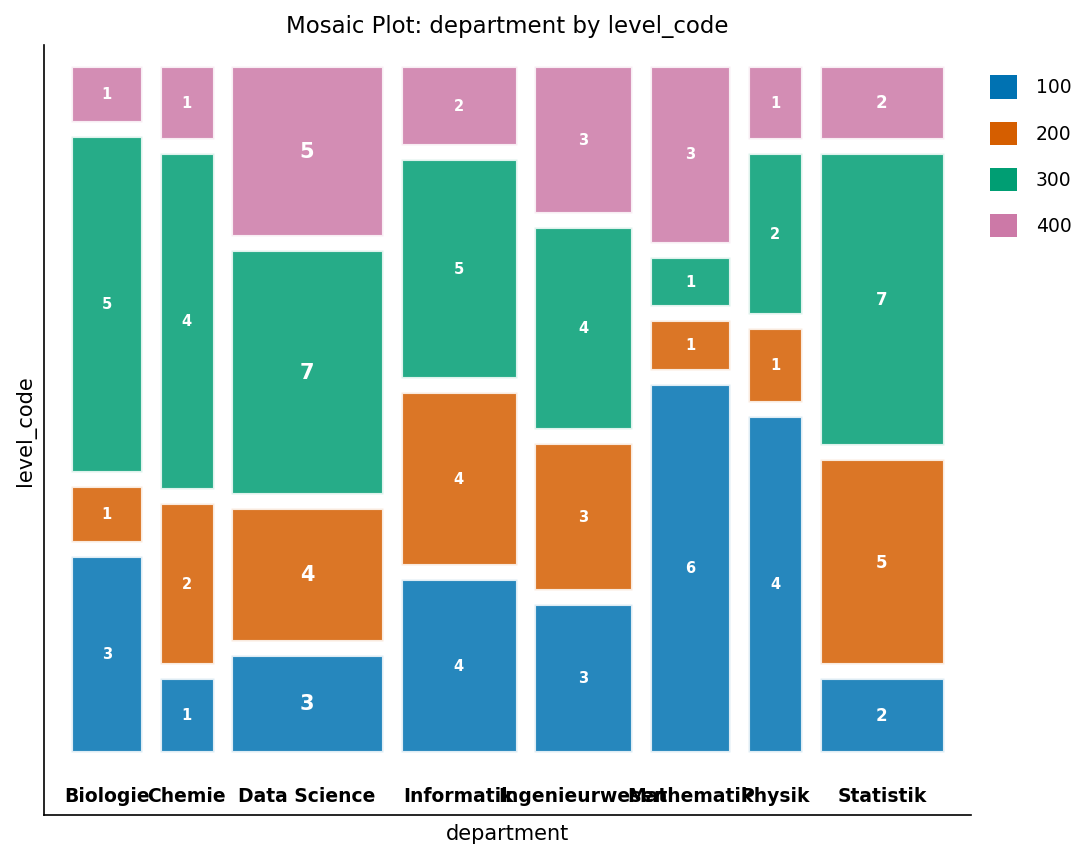

In [3]:
/* --------------------------------------------------------
   Basis-Abdeckung der Lernergebnisse nach Fachbereich
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.course_outcomes mean;
    KLASSE department;
    VAR lo_1 - lo_40;
    BEZEICHNUNG department='Fachbereich';
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    BEZEICHNUNG department='Fachbereich' level_code='Niveau';
AUSFÜHREN;

---


NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


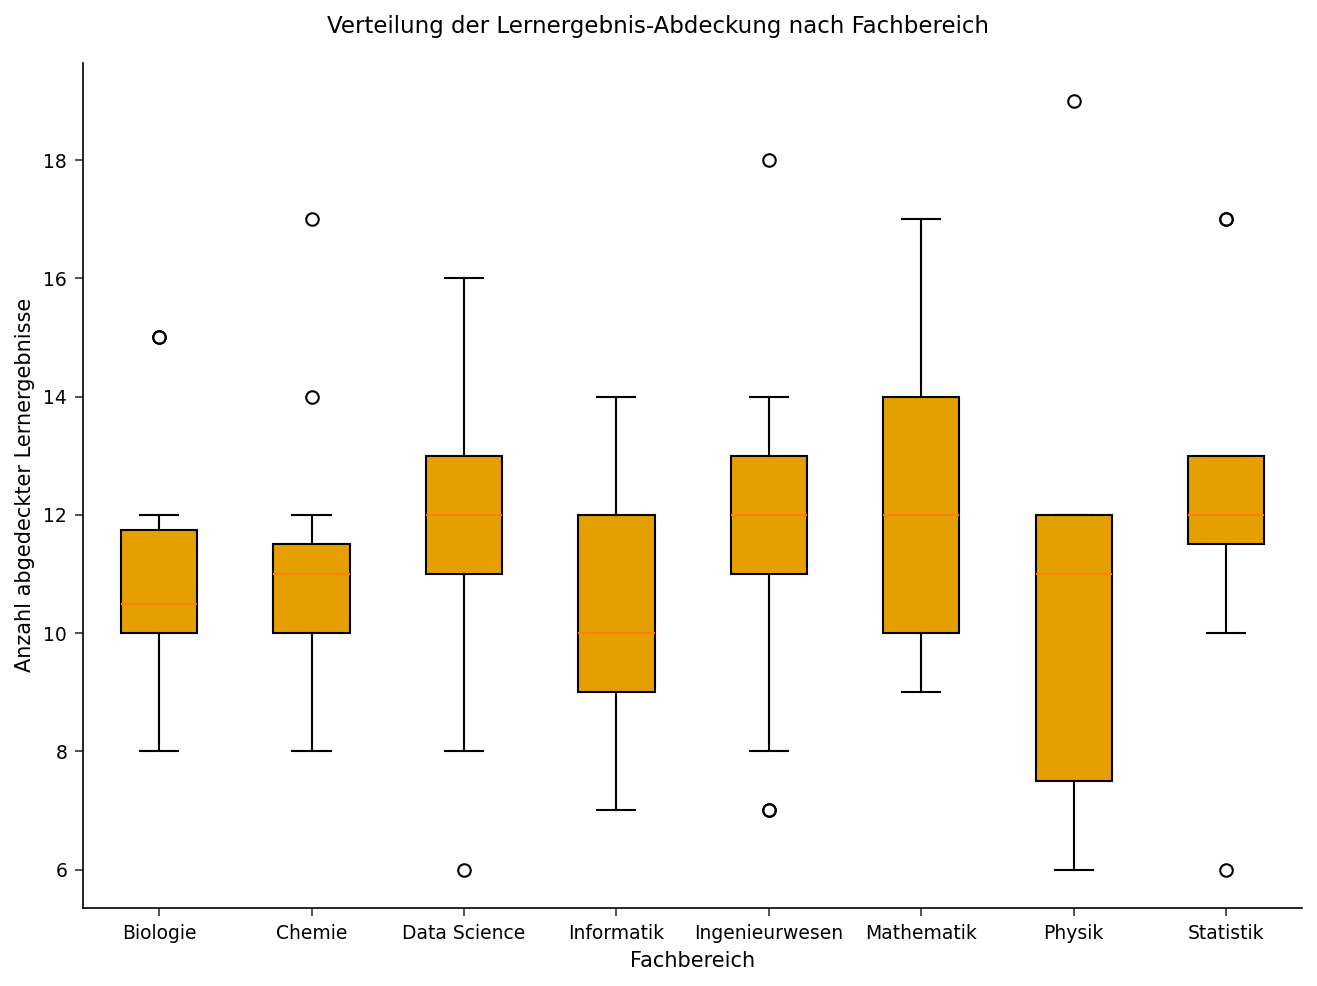

In [4]:
/* --------------------------------------------------------
   Dichte der Ergebnisabdeckung nach Fachbereich
   -------------------------------------------------------- */
DATEN work.outcome_counts;
    FESTLEGEN work.course_outcomes;
    FELD outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS BEZEICHNUNG='Anzahl abgedeckter Lernergebnisse';
    XAXIS BEZEICHNUNG='Fachbereich';
    TITEL 'Verteilung der Lernergebnis-Abdeckung nach Fachbereich';
AUSFÜHREN;

---

In [5]:
/* --------------------------------------------------------
   Konsolidierungs-Panel: die ersten 10 Kurse aus Statistik /
   Data Science (die beiden quantitativ am stärksten
   überlappenden Fachbereiche). Sie werden mit einem
   fortlaufenden Zähler in P01-P10 umbenannt, damit die
   quadratische OUT=-Distanzmatrix saubere, adressierbare
   Spalten erhält; anschließend wird die vollständige paarweise
   Jaccard-DISTANZ-Matrix mit METHOD=DJACCARD berechnet
   (0 = identische Ergebnismengen, 1 = kein gemeinsames Ergebnis).
   -------------------------------------------------------- */
DATEN work.panel10;
    FESTLEGEN work.course_outcomes(WO=(department in ('Statistik' 'Data Science')));
    BEHALTEN_W seq 0;
    seq + 1;
    WENN seq > 10 DANN STOPP;
    panel_id = cat('P', PUT(seq, z2.));
    ENTFERNEN seq;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.panel10 noobs BEZEICHNUNG;
    VAR panel_id course_label department level_code;
    BEZEICHNUNG panel_id = 'Panel-ID' course_label = 'Kurs'
          department = 'Fachbereich' level_code = 'Niveau';
    TITEL 'Konsolidierungs-Panel: Kurse aus Statistik und Data Science';
AUSFÜHREN;

PROZEDUR distance DATEN=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    VAR nominal(lo_1 - lo_40);
    id panel_id;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.panel_dist noobs;
    TITEL 'Paarweise Jaccard-Distanzmatrix (10 Kurse)';
AUSFÜHREN;

                              Konsolidierungs-Panel: Kurse aus Statistik und Data Science                               

Panel-ID     Kurs   Fachbereich  Niveau
P01       CRS0003  Data Science     300
P02       CRS0006  Statistik        300
P03       CRS0014  Data Science     300
P04       CRS0015  Statistik        300
P05       CRS0017  Statistik        200
P06       CRS0019  Data Science     100
P07       CRS0022  Statistik        400
P08       CRS0033  Data Science     200
P09       CRS0038  Statistik        100
P10       CRS0040  Statistik        100

                              Konsolidierungs-Panel: Kurse aus Statistik und Data Science                               

                                       Paarweise Jaccard-Distanzmatrix (10 Kurse)                                       

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P01                0  0.8571428571  0.82608695


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Die quadratische Distanzmatrix in eine gerankte Liste von
   Kurspaaren umformen. Die OUT=-Distanzspalten werden über eine
   explizite Namensliste (P01 P02 ... P10) angesprochen; nur das
   strikte obere Dreieck (Spalte > Zeile) wird behalten, sodass
   jedes ungeordnete Paar einmal erscheint und die Null-Diagonale
   übersprungen wird. Die fünf nächstgelegenen Paare sind die
   Kandidaten für die Konsolidierungsprüfung.
   -------------------------------------------------------- */
DATEN work.similar_courses;
    FESTLEGEN work.panel_dist;
    FELD d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    LÄNGE course_a course_b $8;
    course_a = _name_;
    row + 1;
    AUSFÜHRUNG col = 1 BIS 10;
        WENN col > row DANN AUSFÜHRUNG;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            AUSGABE;
        ENDE;
    ENDE;
    BEHALTEN course_a course_b jaccard_dist;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    VAR jaccard_dist;
    BEZEICHNUNG jaccard_dist='Jaccard-Distanz';
    TITEL 'Verteilung der paarweisen Jaccard-Distanzen (45 Kurspaare)';
AUSFÜHREN;

PROZEDUR SORTIEREN DATEN=work.similar_courses; NACH jaccard_dist; AUSFÜHREN;

DATEN work.top_pairs;
    FESTLEGEN work.similar_courses;
    pair_rank = _n_;
    WENN pair_rank <= 5;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.top_pairs noobs BEZEICHNUNG;
    VAR pair_rank course_a course_b jaccard_dist;
    BEZEICHNUNG pair_rank = 'Rang' course_a = 'Kurs A'
          course_b = 'Kurs B' jaccard_dist = 'Jaccard-Distanz';
    TITEL 'Die fünf ähnlichsten Kurspaare (Konsolidierungs-Kandidaten)';
AUSFÜHREN;

                               Verteilung der paarweisen Jaccard-Distanzen (45 Kurspaare)                               

                                                  The MEANS Procedure

 Variable      Label                  N     Minimum   Lower Quartile      Median        Mean     Maximum
 -------------------------------------------------------------------------------------------------------
 jaccard_dist  Jaccard-Distanz       45       0.588            0.762       0.826       0.818       0.962
 -------------------------------------------------------------------------------------------------------

                              Die fünf ähnlichsten Kurspaare (Konsolidierungs-Kandidaten)                               

Rang  Kurs A  Kurs B  Jaccard-Distanz
   1  P02     P10               0.588
   2  P03     P04                 0.6
   3  P03     P05               0.667
   4  P02     P04               0.684
   5  P02     P07               0.684




NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                     Nicht abgedeckte Lernergebnisse je Fachbereich                                     

                                                   The FREQ Procedure

Fachbereich       Frequency    Percent
---------------------------------------
Biologie                  8     26.67
Chemie                    2      6.67
Informatik                3     10.00
Ingenieurwesen            2      6.67
Mathematik                4     13.33
Physik                    8     26.67
Statistik                 3     10.00
                                  Beispielhafte Lernergebnis-Lücken (erste 12 von 30)                                   

Fachbereich  Nicht abgedecktes Lernergebnis
Biologie     LO02
Biologie     LO10
Biologie     LO15
Biologie     LO16
Biologie     LO17
Biologie     LO18
Biologie     LO36
Biologie     LO37
Chemie       LO02
Chemie       LO12
Informatik   LO29
Informatik   LO35

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


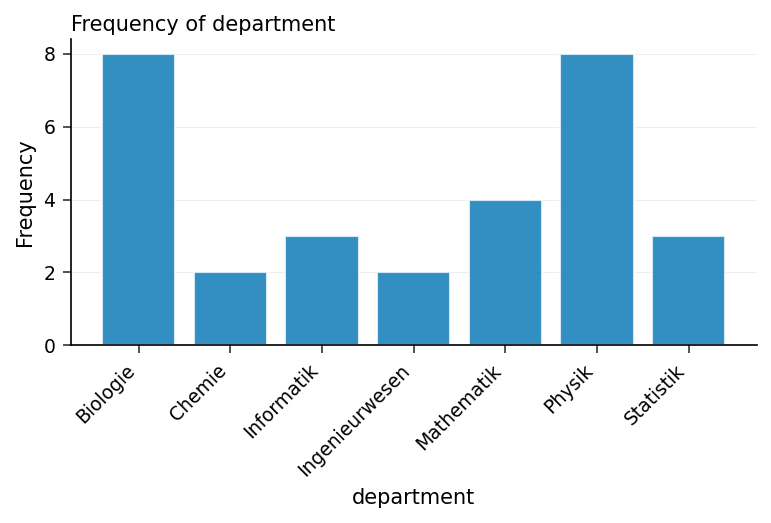

In [7]:
/* --------------------------------------------------------
   Ergebnis-Lücken: Lernergebnisse, die KEIN Kurs eines
   Fachbereichs abdeckt. PROC MEANS summiert jedes binäre
   Ergebnis-Kennzeichen je Fachbereich; eine Summe von null
   bedeutet, dass das Ergebnis im Katalog dieses Fachbereichs
   fehlt.
   -------------------------------------------------------- */
PROZEDUR MITTELWERTE DATEN=work.course_outcomes sum NOPRINT;
    KLASSE department;
    VAR lo_1 - lo_40;
    AUSGABE out=work.dept_coverage(WO=(_type_=1))
        sum=lo_1 - lo_40;
AUSFÜHREN;

DATEN work.outcome_gaps;
    FESTLEGEN work.dept_coverage;
    FELD outcomes[40] lo_1 - lo_40;
    AUSFÜHRUNG lo = 1 BIS 40;
        outcome_id = cat('LO', PUT(lo, z2.));
        courses_covering = outcomes[lo];
        WENN courses_covering = 0 DANN AUSFÜHRUNG;
            gap_flag = 1;
            AUSGABE;
        ENDE;
    ENDE;
    BEHALTEN department outcome_id courses_covering gap_flag;
AUSFÜHREN;

PROZEDUR HÄUFIGKEITEN DATEN=work.outcome_gaps;
    TABLES department / nocum;
    BEZEICHNUNG department='Fachbereich';
    TITEL 'Nicht abgedeckte Lernergebnisse je Fachbereich';
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=work.outcome_gaps(obs=12) noobs BEZEICHNUNG;
    VAR department outcome_id;
    BEZEICHNUNG department = 'Fachbereich' outcome_id = 'Nicht abgedecktes Lernergebnis';
    TITEL 'Beispielhafte Lernergebnis-Lücken (erste 12 von 30)';
AUSFÜHREN;

---

### Interpretation

**Konsolidierungs-Panel.** Über die 45 ungeordneten Paare im Panel aus
10 Kursen der Bereiche Statistik / Data Science reicht die
Jaccard-Distanz von 0.588 bis 0.962 bei einem Median von 0.826 (Mittel
0.818). Das nächstgelegene Paar ist P02 und P10 mit einer Distanz von
0.588, gefolgt von P03–P04 mit 0.600 und P03–P05 mit 0.667. Selbst die
ähnlichsten Kurse unterscheiden sich noch bei rund 59 % ihrer
abgedeckten Lernergebnisse, sodass dieses Verzeichnis **keine
nahezu-doppelten Kurse** enthält — es gibt kein Paar, das ein Ausschuss
unmittelbar zusammenlegen könnte. Die gerankte Liste weist stattdessen
auf die wenigen Paare hin, die vor dem nächsten Verzeichniszyklus einen
manuellen Lehrplan-Vergleich wert sind; die Paare mit der höchsten
Distanz (nahe 0.962) bestätigen, dass Kurse aus Statistik und Data
Science trotz gemeinsamer Fachbereichs-Nachbarschaft wirklich
unterschiedliche Ergebnismengen umspannen.

**Ergebnis-Lücken.** Dreißig Lücken nach Fachbereich und Lernergebnis
treten im Verzeichnis auf. Die laborlastigen Disziplinen tragen die
meisten: **Biologie** und **Physik** lassen jeweils 8 der 40
akkreditierten Lernergebnisse unabgedeckt, gefolgt von **Mathematik**
(4). Die quantitativen Fachbereiche sind am besten abgedeckt —
**Chemie** und **Ingenieurwesen** verfehlen nur jeweils 2
Lernergebnisse. Diese Lücken sind die naheliegenden Ziele für die
Entwicklung neuer Kurse oder für Cross-Listing: ein Lernergebnis, das
in einem ganzen Fachbereich fehlt, ist ein Abdeckungsrisiko bei der
Akkreditierungserneuerung, während die Konsolidierungsliste das
gegenteilige Problem des redundanten Aufwands adressiert. Zusammen
ermöglichen die beiden Artefakte dem Ausschuss, das Verzeichnis von
beiden Enden her zu straffen — Überschneidungen zu beschneiden und
Leerstellen zu füllen — mit einem einzigen mengenbasierten Distanzmaß.

---

In [8]:
/* --------------------------------------------------------
   Die gerankten Konsolidierungs-Kandidaten und die
   Fachbereichs-Lückenkarte für den Lehrplan-Ausschuss
   exportieren.
   -------------------------------------------------------- */
PROZEDUR EXPORT DATEN=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;

PROZEDUR EXPORT DATEN=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>